# tES 77.7 Hz — один период, stereo WAV

Генерация прямоугольника с нулевым средним, проверка через `pulse_analysis`.
WAV для пресета кладём в `presets/`.

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

from pulse_analysis import analyze_rect_pulses

# --- параметры формы ---
F_TARGET_HZ = 77.7
DUTY = 0.2907905460472698  # медиана tes1.5_05M.zip CH2 (steady)
FS_HZ = 44100  # 8000 → N=103, f≈77.67 Hz

PEAK_INT16 = 32767
OUT_WAV = Path("../presets/tes-77hz.wav")
VERIFY_TILES = 64  # для pulse_analysis нужно несколько периодов

In [2]:
def period_samples(fs: int, f_hz: float) -> int:
    """N сэмплов на период: минимум |fs/N − f_hz| среди соседних целых."""
    n0 = int(round(fs / f_hz))
    best = min(range(max(n0 - 2, 2), n0 + 3), key=lambda n: abs(fs / n - f_hz))
    return best


def one_period_bipolar_rect(
    fs: int,
    f_hz: float,
    duty: float,
    peak: int = PEAK_INT16,
) -> tuple[np.ndarray, np.ndarray, int, float]:
    """Один период: +peak (duty), B (1-duty), нулевое среднее. Возврат: mono, stereo int16, N, f_actual."""
    if not 0 < duty < 1:
        raise ValueError("duty must be in (0, 1)")
    n = period_samples(fs, f_hz)
    n_hi = int(round(n * duty))
    n_hi = min(max(n_hi, 1), n - 1)
    n_lo = n - n_hi
    b = -duty / (1.0 - duty)
    low = int(round(peak * b))
    mono = np.concatenate([np.full(n_hi, peak, dtype=np.int16), np.full(n_lo, low, dtype=np.int16)])
    assert mono.size == n
    stereo = np.column_stack([mono, mono])
    f_actual = fs / n
    return mono, stereo, n, f_actual


def wav_crest_factor(mono: np.ndarray) -> float:
    x = mono.astype(np.float64)
    xc = x - x.mean()
    rms = np.sqrt(np.mean(xc**2))
    if rms <= 0:
        return float("nan")
    return np.max(np.abs(x)) / rms


def check_wav_limits(n: int, fs: int) -> None:
    if n > 4096:
        raise ValueError(f"period {n} samples > DAC_MAX_WAVE_SAMPLES 4096")
    supported = {8000, 16000, 22050, 32000, 44100, 48000, 96000, 192000, 384000}
    if fs not in supported:
        raise ValueError(f"Fs {fs} not in DAC supported set")

period_n 568 f_actual Hz 77.64084507042253 err vs 77.7% -0.07613247049867988
duty target 0.2907905460472698 duty samples 0.2904929577464789
mean (int16) -13.644366197183098 mean (norm) -0.0004164057190826713
peak+ 32767 peak- -13435
crest K (left) 1.562175224927207


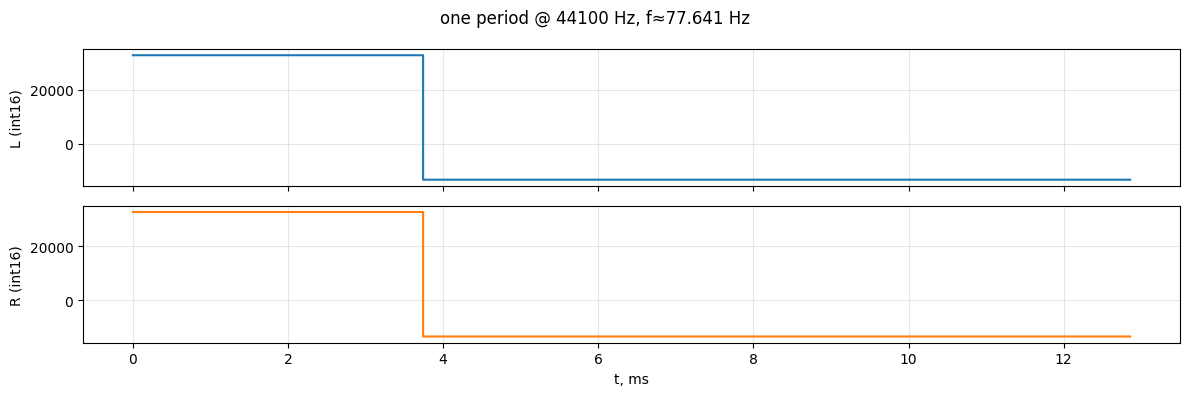

In [3]:
mono, stereo, period_n, f_actual = one_period_bipolar_rect(FS_HZ, F_TARGET_HZ, DUTY)
check_wav_limits(period_n, FS_HZ)

x = mono.astype(np.float64)
print("period_n", period_n, "f_actual Hz", f_actual, "err vs 77.7%", 100 * (f_actual / F_TARGET_HZ - 1))
print("duty target", DUTY, "duty samples", np.sum(mono > 0) / period_n)
print("mean (int16)", mono.mean(), "mean (norm)", (x / PEAK_INT16).mean())
print("peak+", mono.max(), "peak-", mono.min())
print("crest K (left)", wav_crest_factor(mono))

fig, ax = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
t = np.arange(period_n) / FS_HZ * 1e3
ax[0].step(t, mono, where="post")
ax[0].set_ylabel("L (int16)")
ax[0].grid(True, alpha=0.3)
ax[1].step(t, stereo[:, 1], where="post", color="C1")
ax[1].set_ylabel("R (int16)")
ax[1].set_xlabel("t, ms")
ax[1].grid(True, alpha=0.3)
plt.suptitle(f"one period @ {FS_HZ} Hz, f≈{f_actual:.3f} Hz")
plt.tight_layout()
plt.show()

In [4]:
# pulse_analysis: один период слишком короткий — повторяем луп
sig = mono.astype(np.float64) / PEAK_INT16
sig_long = np.tile(sig, VERIFY_TILES)
ps = analyze_rect_pulses(sig_long, FS_HZ)
s = ps.steady
print("analyze_rect_pulses (L, tiled x", VERIFY_TILES, ")")
print("  n", ps.period.size, "steady", s.sum())
print("  period_n med", np.median(ps.period_n[s]))
print("  f_Hz med", 1 / np.median(ps.period[s]))
print("  duty med", np.nanmedian(ps.duty[s]))
print("  pulse_s med", np.nanmedian(ps.pulse[s]))

analyze_rect_pulses (L, tiled x 64 )
  n 62 steady 62
  period_n med 568.0
  f_Hz med 77.64084507042253
  duty med 0.2904929577464789
  pulse_s med 0.0037414965986394557


In [5]:
OUT_WAV.parent.mkdir(parents=True, exist_ok=True)
wavfile.write(OUT_WAV, FS_HZ, stereo)
print("written", OUT_WAV.resolve())

sr, back = wavfile.read(OUT_WAV)
assert sr == FS_HZ
assert back.ndim == 2 and back.shape[1] == 2
assert np.array_equal(back[:, 0], back[:, 1])
print("readback OK, frames", back.shape[0], "channels", back.shape[1])

written /home/sk/Yandex.Disk/Obsidian Vault/tPRNS/tRNS/presets/tes-77hz.wav
readback OK, frames 568 channels 2


## Границы `amplitude_mA` для YAML (×1.5 peak/RMS, ÷2 стерео)

min 0.37, default 0.75, max 1.13, step 0.01 — см. пресет `tes-77hz.yaml`.

In [6]:
for base in (0.5, 1.0, 1.5):
    ui = base * 1.5 / 2
    print(f"base {base} mA → amplitude_mA {ui:.2f}")

base 0.5 mA → amplitude_mA 0.38
base 1.0 mA → amplitude_mA 0.75
base 1.5 mA → amplitude_mA 1.12
